In [1]:
import xarray as xr
import rioxarray
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.ndimage import median_filter, minimum_filter, maximum_filter, uniform_filter
import lightgbm as lgb 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
from tqdm import tqdm
import joblib
from pathlib import Path

In [2]:
RAW_XY_FOLDERPATH = Path('../data/silver/Xy-2021')

# Load data

In [3]:
raw_Xy = pd.read_parquet(RAW_XY_FOLDERPATH / "Xy.parquet")
metadata_df = pd.read_parquet(RAW_XY_FOLDERPATH / "metadata_df.parquet")

raw_Xy.head(1)

,red,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,red_5x5_var,red_11x11_median,...,scl,tci,ndvi,evi,evi2,ndre_b5,ndre_b6,ndre_b7,gndvi,ndwi
0,0.133333,0.133333,0.121569,0.141176,0.007843,0.133333,0.109804,0.145098,0.019608,0.12549,...,NOT_VEGETATED,0.03115,0.218391,0.074277,-0.116667,0.081633,0.039216,0.009524,0.12192,-0.116667


# Build Xy

In [8]:
def get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    features += ['scl', "region"]
    features += ['tci', 'ndvi', 'evi', 'evi2', 'ndre_b5', 'ndre_b6', 'ndre_b7', 'gndvi', 'ndwi']
    features += ['valid_observations']
    features += ['cloud_confidence']
    return X[features + ['y']]

Xy = get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features(raw_Xy)
Xy.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,...,evi,evi2,ndre_b5,ndre_b6,ndre_b7,gndvi,ndwi,valid_observations,cloud_confidence,y
0,0.066667,0.094118,0.133333,0.176471,0.192157,0.203922,0.207843,0.207843,0.262745,0.219608,...,0.074277,-0.116667,0.081633,0.039216,0.009524,0.12192,-0.116667,7,0,False


# Prep hyperparam optimization

In [20]:
import numpy as np
import optuna
import lightgbm as lgb
from sklearn.model_selection import cross_validate, GroupKFold

def optuna_objective_factory(X, y, groups, always_train_mask, n_splits):
    """
    always_train_mask: A boolean list/array of the same length as X. 
                       True means the sample is always used in training.
                       False means the sample is rotated via GroupKFold.
    """
    
    # --- 1. Pre-calculate the custom CV splits once ---
    always_train_mask = np.array(always_train_mask)
    
    # Get absolute indices for both groups
    fixed_indices = np.where(always_train_mask)[0]
    rot_indices = np.where(~always_train_mask)[0]
    
    # Extract just the groups for the rotating portion
    groups_rot = np.array(groups)[rot_indices]
    
    # GroupKFold only needs the shape and the groups, so we can use a dummy array
    dummy_X_rot = np.zeros(len(rot_indices))
    
    gkf = GroupKFold(n_splits=n_splits)
    custom_cv = []
    
    # Generate the splits only on the rotating data
    for train_idx_rel, val_idx_rel in gkf.split(dummy_X_rot, dummy_X_rot, groups_rot):
        
        # Map the relative fold indices back to the absolute indices of the full dataset
        train_idx_rot = rot_indices[train_idx_rel]
        val_idx_rot = rot_indices[val_idx_rel]
        
        # Combine the fixed indices with the rotating training fold
        full_train_idx = np.concatenate([fixed_indices, train_idx_rot])
        
        # Append the (train, validation) tuple scikit-learn expects
        custom_cv.append((full_train_idx, val_idx_rot))

    # Pre-calculate the validation sizes for each fold
    val_sizes = [len(val_idx) for _, val_idx in custom_cv]

    # --- 2. The Objective Function ---
    def objective(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 2, 15),
            'num_leaves': trial.suggest_int('num_leaves', 10, 256),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'n_jobs': -1,
            'verbose': -1,
            'random_state': 42
        }
        
        model = lgb.LGBMClassifier(**param)
        
        # Pass the pre-computed custom_cv list to the cv parameter
        scores = cross_validate(model, X, y, cv=custom_cv, scoring=['f1', 'precision', 'recall'], n_jobs=1, )
        
        trial.set_user_attr('f1s', scores["test_f1"])
        trial.set_user_attr('precisions', scores["test_precision"])
        trial.set_user_attr('recalls', scores["test_recall"])
        
        # Add the validation set sizes to the trial attributes
        trial.set_user_attr('val_sizes', val_sizes)
        
        return np.median(scores['test_f1'])

    return objective

# Train:test split

In [21]:
def train_test_split(Xy, metadata_df, region: str, test_size=0.5):
    """Split a train/test set, where all test samples are located within a region."""
    region_mask = Xy.region.apply(lambda x: x.lower()) == region

    if not region_mask.sum():
        raise ValueError(f'Region {region} not found.')

    # Figure out which folds are for train/val and which for test
    region_fold_idxs = metadata_df.fold_idx[region_mask].unique()
    n_test_folds = int(np.floor(test_size * len(region_fold_idxs)))
    test_fold_idxs = np.random.choice(region_fold_idxs, size=n_test_folds, replace=False)
    test_mask = metadata_df.fold_idx.isin(test_fold_idxs)
    print(f"{len(test_fold_idxs)}/{len(region_fold_idxs)} regions for testing ({test_mask.sum()} points)")
    
    return Xy[~test_mask], metadata_df[~test_mask], Xy[test_mask], metadata_df[test_mask]

Xy_train, train_metadata_df, Xy_test, test_metadata_df = train_test_split(Xy, metadata_df, 'upper east', 0.5)
Xy_train.head(1)

50/100 regions for testing (4365 points)


,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,...,evi,evi2,ndre_b5,ndre_b6,ndre_b7,gndvi,ndwi,valid_observations,cloud_confidence,y
57,0.043137,0.058824,0.07451,0.12549,0.156863,0.176471,0.172549,0.180392,0.196078,0.133333,...,0.126135,-0.06383,0.179487,0.069767,0.010989,0.18137,-0.06383,7,0,True


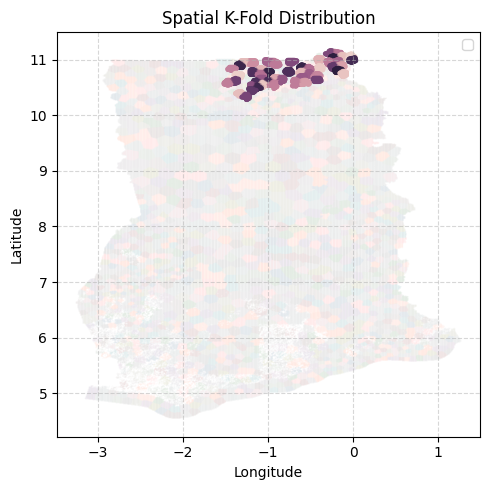

In [22]:
# Plot the folds
plt.figure(figsize=(5, 5))
sns.scatterplot(data=train_metadata_df, x='lon', y='lat', hue='fold_idx', palette='tab20', s=1, alpha=0.02, edgecolor=None)
sns.scatterplot(data=test_metadata_df, x='lon', y='lat', hue='fold_idx', color='r', s=10, alpha=1, edgecolor=None)

plt.title('Spatial K-Fold Distribution')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend([])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# Train

In [23]:
import numpy as np
import optuna
import lightgbm as lgb
from scipy import stats
from sklearn.metrics import f1_score, precision_score, recall_score

def train_test_lgbm(X_train, y_train, X_test, y_test, groups, always_train_mask, n_splits=10, n_trials=3, n_clfs=5, ci_level=0.95):
    print("Starting Optuna hyperparameter optimization...")
    study = optuna.create_study(direction="maximize") 
    study.optimize(optuna_objective_factory(X_train, y_train, groups, always_train_mask, n_splits), n_trials=n_trials, show_progress_bar=True)
    
    # Store the best params (removing random_state if it's there, as we will override it)
    best_params = study.best_params.copy()
    if 'random_state' in best_params:
        del best_params['random_state']

    clfs = []
    yhats_train = []
    yhats_test = []
    
    # Dictionaries to store the metrics across the n runs
    metrics = {
        'train': {'f1': [], 'precision': [], 'recall': []},
        'test':  {'f1': [], 'precision': [], 'recall': []}
    }

    print(f"\nTraining {n_clfs} models with best hyperparameters and different random seeds...")
    
    for i in range(n_clfs):
        # Inject a unique random state for each iteration
        seed = 42 + i
        clf = lgb.LGBMClassifier(**best_params, random_state=seed)
        clf.fit(X_train, y_train)
        
        yhat_train = clf.predict(X_train)
        yhat_test = clf.predict(X_test)
        
        # Store models and predictions
        clfs.append(clf)
        yhats_train.append(yhat_train)
        yhats_test.append(yhat_test)
        
        # Calculate and store metrics for this specific seed
        metrics['train']['f1'].append(f1_score(y_train, yhat_train, zero_division=0))
        metrics['train']['precision'].append(precision_score(y_train, yhat_train, zero_division=0))
        metrics['train']['recall'].append(recall_score(y_train, yhat_train, zero_division=0))
        
        metrics['test']['f1'].append(f1_score(y_test, yhat_test, zero_division=0))
        metrics['test']['precision'].append(precision_score(y_test, yhat_test, zero_division=0))
        metrics['test']['recall'].append(recall_score(y_test, yhat_test, zero_division=0))

    # --- Helper to calculate and format Mean ± CI ---
    def calc_ci_string(data_array):
        mean_val = np.mean(data_array)
        if n_clfs < 2:
            return f"{mean_val:.4f}"
            
        se = stats.sem(data_array)
        # Degrees of freedom is n-1. Calculate the t-critical value.
        h = se * stats.t.ppf((1 + ci_level) / 2., n_clfs - 1)
        return f"{mean_val:.4f} ± {h:.4f}"

    print(f"\n--- OPTIMIZED MODEL EVALUATION ({n_clfs} Runs, {int(ci_level*100)}% CI) ---")
    print("TRAIN")
    print(f"- F1:        {calc_ci_string(metrics['train']['f1'])}")
    print(f"- Precision: {calc_ci_string(metrics['train']['precision'])}")
    print(f"- Recall:    {calc_ci_string(metrics['train']['recall'])}")
    
    print("\nTEST")
    print(f"- F1:        {calc_ci_string(metrics['test']['f1'])}")
    print(f"- Precision: {calc_ci_string(metrics['test']['precision'])}")
    print(f"- Recall:    {calc_ci_string(metrics['test']['recall'])}")

    # Return the lists of models, predictions (shape: [n_clfs, n_samples]), and optuna attrs
    return clfs, np.array(yhats_train), np.array(yhats_test), study.best_trial.user_attrs

In [26]:
def train_region(Xy, metadata_df, region):
    
    # Get train:test
    Xy_train, train_metadata_df, Xy_test, test_metadata_df = train_test_split(Xy, metadata_df, region.lower(), 0.5)    
    X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
    X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

    # Train
    outside_region_mask = Xy_train.region.apply(lambda x: x.lower()) != region.lower()
    clf, _, _, user_attrs = train_test_lgbm(X_train, y_train, X_test, y_test, train_metadata_df.fold_idx, outside_region_mask, n_trials=3);
    
    # Dump
    payload = {
        'X_train': X_train,
        'y_train': y_train,
        'metadata_df_train':  train_metadata_df,
        'X_test': X_test,
        'y_test': y_test,
        'metadata_df_test':  test_metadata_df,
        'clf': clf,
        "user_attrs": user_attrs,
    }
    
    joblib.dump(payload, f'trained-{region.lower()}-2021.joblib')

In [27]:
train_region(Xy, metadata_df, 'ashanti')

[I 2026-06-22 14:55:04,016] A new study created in memory with name: no-name-f2f978b3-15d0-4a31-809a-21e8d297fba3


50/100 regions for testing (11949 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-22 14:55:12,250] Trial 0 finished with value: 0.9184260110142206 and parameters: {'n_estimators': 140, 'learning_rate': 0.047751414288510596, 'max_depth': 4, 'num_leaves': 237, 'subsample': 0.9525255871304303, 'colsample_bytree': 0.7060871368023778, 'min_child_samples': 88}. Best is trial 0 with value: 0.9184260110142206.
[I 2026-06-22 14:56:15,634] Trial 1 finished with value: 0.921955579631636 and parameters: {'n_estimators': 400, 'learning_rate': 0.07906717546413164, 'max_depth': 9, 'num_leaves': 182, 'subsample': 0.7867676461608772, 'colsample_bytree': 0.7529011210047727, 'min_child_samples': 84}. Best is trial 1 with value: 0.921955579631636.
[I 2026-06-22 14:56:19,331] Trial 2 finished with value: 0.9188309078168899 and parameters: {'n_estimators': 59, 'learning_rate': 0.17149551517058775, 'max_depth': 2, 'num_leaves': 172, 'subsample': 0.5993689447544378, 'colsample_bytree': 0.6151979472652541, 'min_child_samples': 59}. Best is trial 1 with value: 0.921955579631636.



In [28]:
train_region(Xy, metadata_df, 'western north')

[I 2026-06-22 14:57:09,927] A new study created in memory with name: no-name-5b6c8ba2-e611-4e9f-9ad3-24c8b6443d49


50/100 regions for testing (4071 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-22 14:57:43,184] Trial 0 finished with value: 0.9903891509433962 and parameters: {'n_estimators': 122, 'learning_rate': 0.010155104499056631, 'max_depth': 9, 'num_leaves': 251, 'subsample': 0.6604128356307427, 'colsample_bytree': 0.5581321913104433, 'min_child_samples': 31}. Best is trial 0 with value: 0.9903891509433962.
[I 2026-06-22 14:57:59,168] Trial 1 finished with value: 0.9924998124953124 and parameters: {'n_estimators': 223, 'learning_rate': 0.1461011854832887, 'max_depth': 5, 'num_leaves': 213, 'subsample': 0.7298978165410284, 'colsample_bytree': 0.6597575783304532, 'min_child_samples': 39}. Best is trial 1 with value: 0.9924998124953124.
[I 2026-06-22 14:58:28,567] Trial 2 finished with value: 0.9898041354945968 and parameters: {'n_estimators': 116, 'learning_rate': 0.011645798239773505, 'max_depth': 14, 'num_leaves': 155, 'subsample': 0.9395726303050396, 'colsample_bytree': 0.5869570546010056, 'min_child_samples': 56}. Best is trial 1 with value: 0.99249981249531

In [29]:
train_region(Xy, metadata_df, 'western')

[I 2026-06-22 14:58:40,586] A new study created in memory with name: no-name-42687a66-db9d-4aab-a27f-d47a8af2b5f2


50/100 regions for testing (6969 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-22 14:58:47,283] Trial 0 finished with value: 0.9713798038357763 and parameters: {'n_estimators': 120, 'learning_rate': 0.09192574276631875, 'max_depth': 2, 'num_leaves': 120, 'subsample': 0.8914756350134223, 'colsample_bytree': 0.8859078799812508, 'min_child_samples': 93}. Best is trial 0 with value: 0.9713798038357763.
[I 2026-06-22 15:00:14,391] Trial 1 finished with value: 0.974391244359921 and parameters: {'n_estimators': 338, 'learning_rate': 0.05660436631191455, 'max_depth': 14, 'num_leaves': 216, 'subsample': 0.9479784783162557, 'colsample_bytree': 0.713881103771876, 'min_child_samples': 93}. Best is trial 1 with value: 0.974391244359921.
[I 2026-06-22 15:01:13,647] Trial 2 finished with value: 0.9735621786604262 and parameters: {'n_estimators': 402, 'learning_rate': 0.012065396648363539, 'max_depth': 11, 'num_leaves': 72, 'subsample': 0.8040834558571128, 'colsample_bytree': 0.6456613732483598, 'min_child_samples': 49}. Best is trial 1 with value: 0.974391244359921.


# Use TCA
https://en.wikipedia.org/wiki/Tasseled_cap_transformation

# Use clustering min ?